# 03 — Service anomaly detection from autoencoder reconstruction error

Second, fully **unsupervised** use of the autoencoders trained in the two
`ML_autoencoder_*` notebooks: a trip that the AE reconstructs poorly does
not follow the "normal service" patterns the AE compressed — a candidate
service anomaly (disruption, detour, stall, telemetry failure).

Scores are **out-of-fold**: each trip was scored by the AE of the CV fold
where it was held out, so no trip is scored by a model that saw it.

Validation strategy (no ground-truth anomaly labels exist):
1. **Known degraded-telemetry days** (Mar 20, 22, 28) should score higher.
2. **Rain** should push scores up.
3. **Case studies** of the top-scoring trips should show interpretable
   failure modes.

In [1]:
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.manifold import TSNE

import netmob_prep as prep

sns.set_theme(style="whitegrid")
RANDOM_SEED = 42
OUT = "./artifacts_anomaly"
os.makedirs(OUT, exist_ok=True)

ANOM_PCT = 95           # anomaly = score above this percentile
TSNE_MAX_POINTS = 5000

meta = pd.read_parquet("./cache/trips_meta.parquet").set_index("trip_instance_id")
scores = {}
for tag, adir in [("cnn", "./artifacts_ae_cnn"), ("lstm", "./artifacts_ae_lstm")]:
    s = pd.read_csv(f"{adir}/anomaly_scores.csv").set_index("trip_instance_id")
    scores[tag] = s
print({k: len(v) for k, v in scores.items()}, "out-of-fold scores")

{'cnn': 22605, 'lstm': 22605} out-of-fold scores


## 1. Scores, thresholds, and CNN-vs-LSTM agreement

Reconstruction MSE is heavy-tailed → standardize `log(mse)`; a trip is
flagged anomalous above the 95th percentile of its own AE's distribution.

anomalies: CNN 1131, LSTM 1131, both 705, Jaccard 0.45
score correlation (Pearson): 0.876


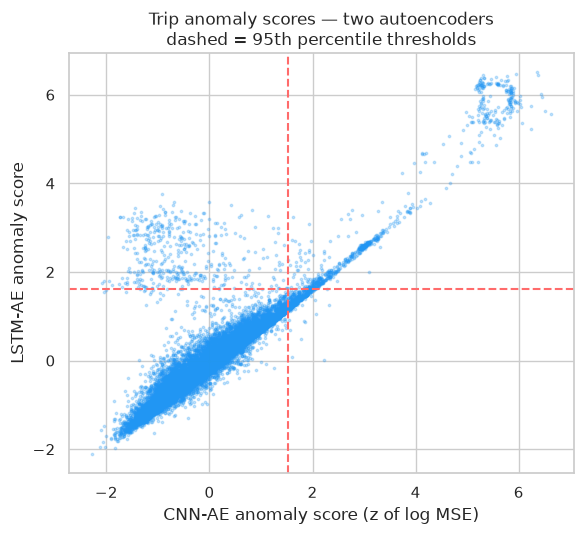

In [2]:
df = meta.copy()
for tag in ("cnn", "lstm"):
    s = scores[tag]["recon_mse"].reindex(df.index)
    logs = np.log(s)
    df[f"score_{tag}"] = (logs - logs.mean()) / logs.std()
    df[f"anom_{tag}"] = df[f"score_{tag}"] > np.nanpercentile(df[f"score_{tag}"], ANOM_PCT)
df = df.dropna(subset=["score_cnn", "score_lstm"])

both = (df["anom_cnn"] & df["anom_lstm"]).sum()
either = (df["anom_cnn"] | df["anom_lstm"]).sum()
print(f"anomalies: CNN {df['anom_cnn'].sum()}, LSTM {df['anom_lstm'].sum()}, "
      f"both {both}, Jaccard {both / max(1, either):.2f}")
print(f"score correlation (Pearson): "
      f"{df['score_cnn'].corr(df['score_lstm']):.3f}")

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(df["score_cnn"], df["score_lstm"], s=3, alpha=0.25, color="#2196F3")
ax.axvline(np.nanpercentile(df["score_cnn"], ANOM_PCT), color="#FF6B6B", ls="--")
ax.axhline(np.nanpercentile(df["score_lstm"], ANOM_PCT), color="#FF6B6B", ls="--")
ax.set_xlabel("CNN-AE anomaly score (z of log MSE)")
ax.set_ylabel("LSTM-AE anomaly score")
ax.set_title(f"Trip anomaly scores — two autoencoders\n"
             f"dashed = {ANOM_PCT}th percentile thresholds")
plt.tight_layout(); plt.savefig(f"{OUT}/score_agreement.png", dpi=140); plt.show()

## 2. Do known degraded days score higher?

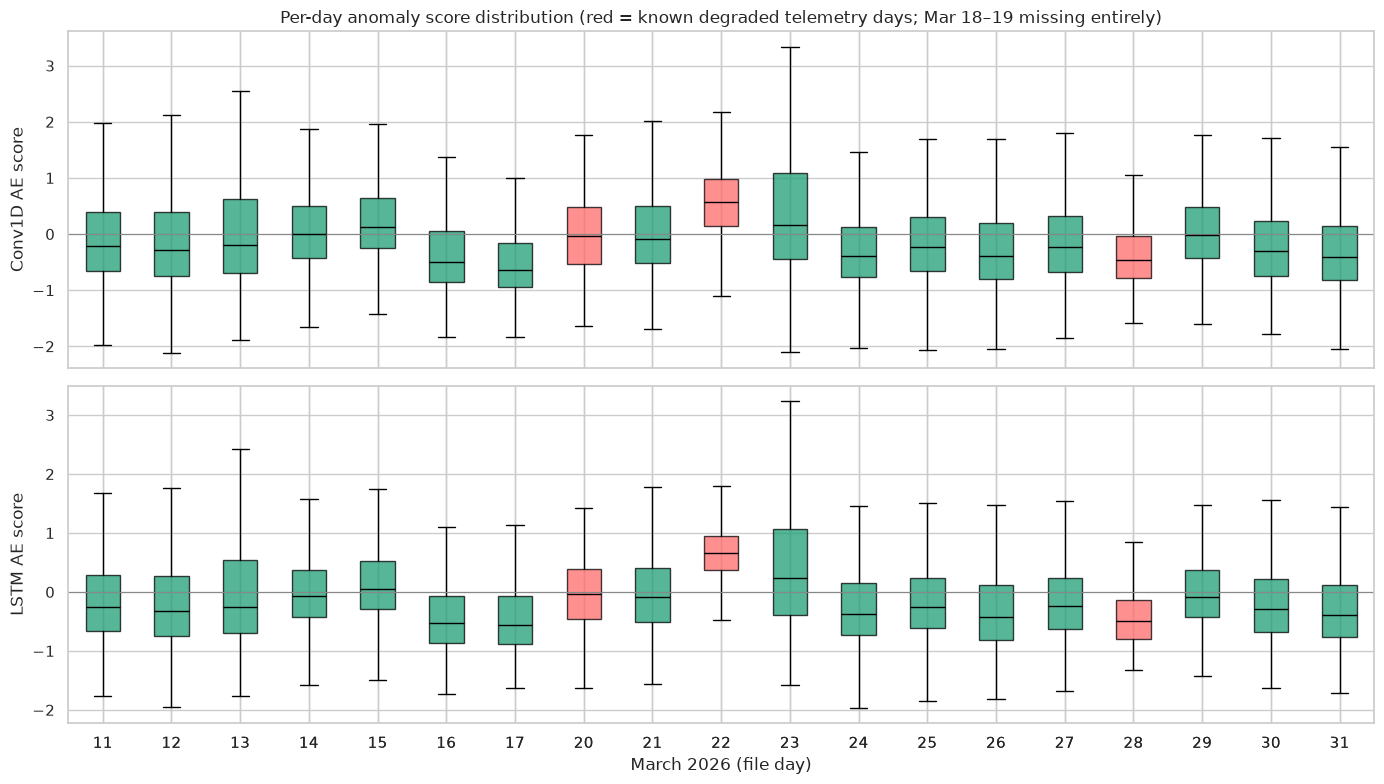

In [3]:
df["date"] = df["file_date"]
all_days = sorted(df["date"].unique())
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, tag, name in [(axes[0], "cnn", "Conv1D AE"), (axes[1], "lstm", "LSTM AE")]:
    data = [df.loc[df["date"] == d, f"score_{tag}"] for d in all_days]
    bp = ax.boxplot(data, tick_labels=[d[8:] for d in all_days], showfliers=False,
                    patch_artist=True, medianprops={"color": "black"})
    for patch, d in zip(bp["boxes"], all_days):
        patch.set_facecolor("#FF6B6B" if d in prep.DEGRADED_DAYS else "#1D9E75")
        patch.set_alpha(0.75)
    ax.set_ylabel(f"{name} score")
    ax.axhline(0, color="#888", lw=0.8)
axes[0].set_title("Per-day anomaly score distribution "
                  "(red = known degraded telemetry days; Mar 18–19 missing entirely)")
axes[1].set_xlabel("March 2026 (file day)")
plt.tight_layout(); plt.savefig(f"{OUT}/per_day_scores.png", dpi=140); plt.show()

In [4]:
for tag in ("cnn", "lstm"):
    deg = df.loc[df["degraded_day"] == 1, f"score_{tag}"]
    nor = df.loc[df["degraded_day"] == 0, f"score_{tag}"]
    u, p = stats.mannwhitneyu(deg, nor, alternative="greater")
    print(f"{tag.upper()}-AE: degraded-day median {deg.median():+.2f} vs "
          f"normal {nor.median():+.2f} | Mann-Whitney U one-sided p = {p:.2e} | "
          f"anomaly rate {df.loc[df['degraded_day'] == 1, f'anom_{tag}'].mean():.1%} "
          f"vs {df.loc[df['degraded_day'] == 0, f'anom_{tag}'].mean():.1%}")

CNN-AE: degraded-day median +0.21 vs normal -0.20 | Mann-Whitney U one-sided p = 6.16e-67 | anomaly rate 4.3% vs 5.1%
LSTM-AE: degraded-day median +0.31 vs normal -0.22 | Mann-Whitney U one-sided p = 1.49e-113 | anomaly rate 2.4% vs 5.3%


## 3. Rain vs anomaly score

/tmp/ipykernel_31345/1413637773.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="rainy", y=f"score_{tag}", ax=ax, showfliers=False,
/tmp/ipykernel_31345/1413637773.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["dry", "rain"])
/tmp/ipykernel_31345/1413637773.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="rainy", y=f"score_{tag}", ax=ax, showfliers=False,
/tmp/ipykernel_31345/1413637773.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocat

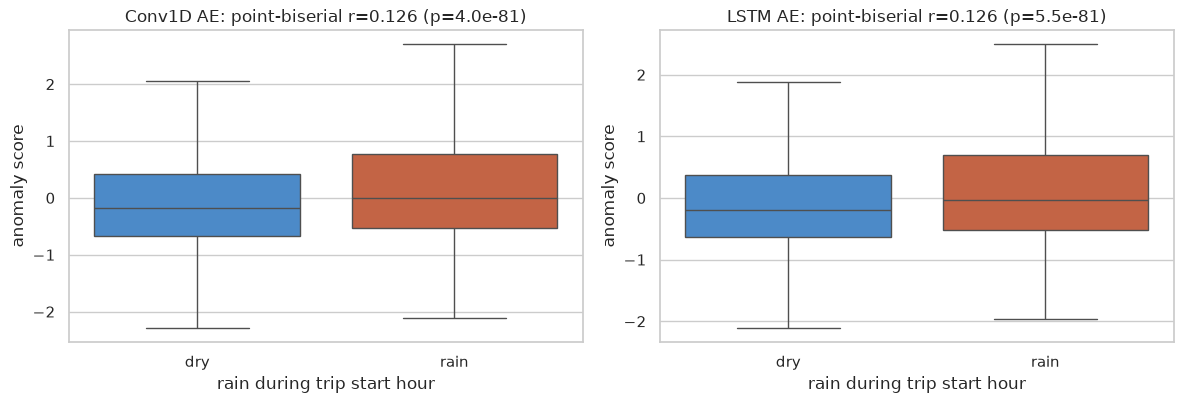

In [5]:
rain_utc = prep.load_rain_by_utc_hour()
starts = (pd.to_datetime(df["start_time"]) + pd.Timedelta(hours=3)).dt.floor("h")
df["rain_mm_trip"] = rain_utc.reindex(starts).fillna(0.0).to_numpy()
df["rainy"] = (df["rain_mm_trip"] > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, tag, name in [(axes[0], "cnn", "Conv1D AE"), (axes[1], "lstm", "LSTM AE")]:
    r, p = stats.pointbiserialr(df["rainy"], df[f"score_{tag}"])
    sns.boxplot(data=df, x="rainy", y=f"score_{tag}", ax=ax, showfliers=False,
                palette=["#378ADD", "#D85A30"])
    ax.set_xticklabels(["dry", "rain"])
    ax.set_title(f"{name}: point-biserial r={r:.3f} (p={p:.1e})")
    ax.set_xlabel("rain during trip start hour"); ax.set_ylabel("anomaly score")
plt.tight_layout(); plt.savefig(f"{OUT}/rain_vs_score.png", dpi=140); plt.show()

## 4. Latent space, coloured three ways

Out-of-fold pooled latents `z` from the CNN AE (test split of every fold →
full coverage of the dataset, subsampled for CPU t-SNE).

t-SNE on 5000 out-of-fold latents...


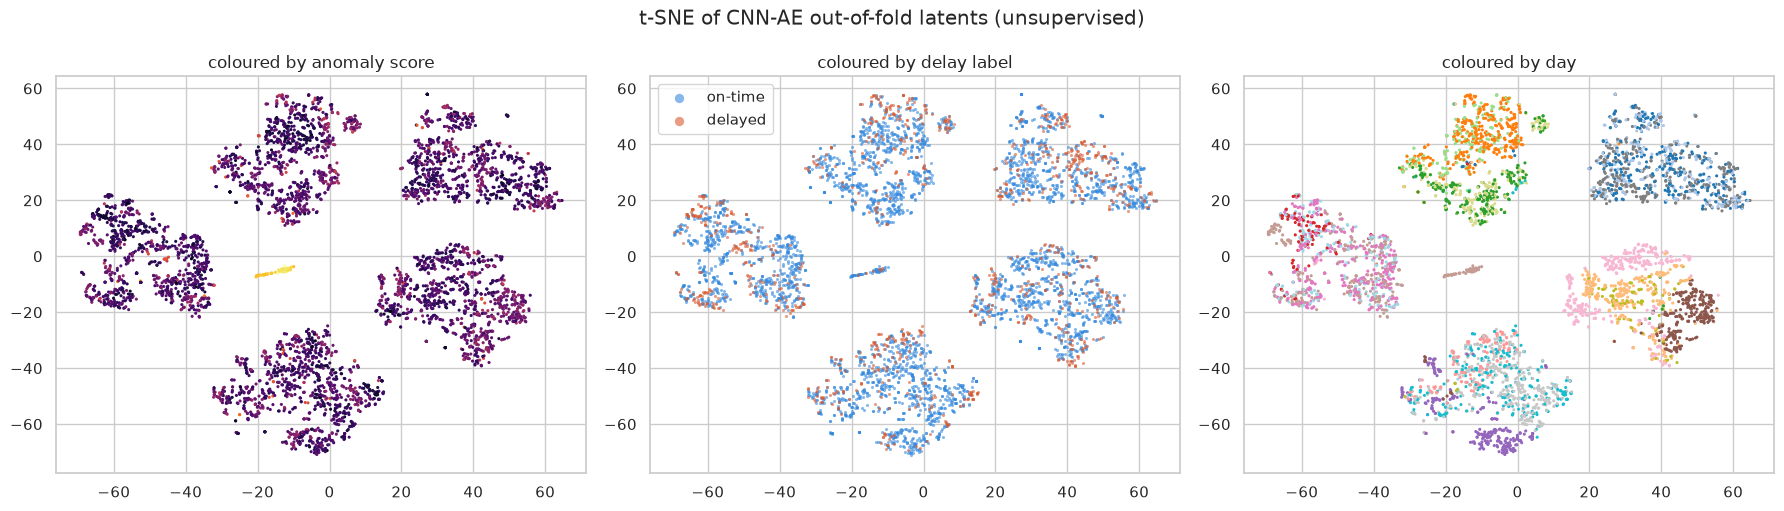

In [6]:
lat = np.load("./artifacts_ae_cnn/latent_vectors.npz", allow_pickle=True)
folds = sorted({int(k.split("_")[0][4:]) for k in lat.files})
z_all = np.vstack([lat[f"fold{f}_z_test"] for f in folds])
ids_all = np.concatenate([lat[f"fold{f}_trip_ids_test"] for f in folds])
sub = pd.DataFrame(index=ids_all).join(
    df[["anom_cnn", "delayed", "date", "score_cnn"]], how="inner")
keep = ~sub["anom_cnn"].isna().to_numpy()
z_all, sub = z_all[keep], sub[keep]

rng = np.random.default_rng(RANDOM_SEED)
if len(z_all) > TSNE_MAX_POINTS:
    sel = rng.choice(len(z_all), TSNE_MAX_POINTS, replace=False)
    z_all, sub = z_all[sel], sub.iloc[sel]
print(f"t-SNE on {len(z_all)} out-of-fold latents...")
z2d = TSNE(n_components=2, perplexity=40, random_state=RANDOM_SEED,
           learning_rate="auto", init="pca", max_iter=1000).fit_transform(z_all)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
axes[0].scatter(z2d[:, 0], z2d[:, 1], c=sub["score_cnn"], cmap="inferno",
                s=5, linewidths=0)
axes[0].set_title("coloured by anomaly score")
for lab, color, name in [(0, "#378ADD", "on-time"), (1, "#D85A30", "delayed")]:
    m = (sub["delayed"] == lab).to_numpy()
    axes[1].scatter(z2d[m, 0], z2d[m, 1], c=color, s=5, alpha=0.6,
                    label=name, linewidths=0)
axes[1].legend(markerscale=3); axes[1].set_title("coloured by delay label")
day_codes = pd.Categorical(sub["date"]).codes
axes[2].scatter(z2d[:, 0], z2d[:, 1], c=day_codes, cmap="tab20", s=5, linewidths=0)
axes[2].set_title("coloured by day")
fig.suptitle("t-SNE of CNN-AE out-of-fold latents (unsupervised)")
plt.tight_layout(); plt.savefig(f"{OUT}/latent_tsne_3ways.png", dpi=140); plt.show()

## 5. Top-20 anomalous trips — case studies

In [7]:
df["score_mean"] = (df["score_cnn"] + df["score_lstm"]) / 2
top20 = (df.sort_values("score_mean", ascending=False).head(20)
         [["date", "line_id", "trip_id", "start_time", "duration_sec",
           "median_delay_sec", "stop_coverage", "rain_mm_trip",
           "score_cnn", "score_lstm", "score_mean", "degraded_day"]])
top20["duration_min"] = (top20["duration_sec"] / 60).round(1)
top20["delay_min"] = (top20["median_delay_sec"] / 60).round(1)
show = top20.drop(columns=["duration_sec", "median_delay_sec"])
print(show.round(2).to_string())
show.to_csv(f"{OUT}/top20_anomalous_trips.csv")

                                date line_id        trip_id           start_time  stop_coverage  rain_mm_trip  score_cnn  score_lstm  score_mean  degraded_day  duration_min  delay_min
trip_instance_id                                                                                                                                                                       
2026-03-23_1477770_U_15   2026-03-23      28   1477770_U_15  2026-03-23 16:31:58           0.89          11.8       6.36        6.50        6.43             0          18.8        0.8
2026-03-23_1497250_U_16   2026-03-23      57   1497250_U_16  2026-03-23 15:57:55           1.00           0.0       6.37        6.45        6.41             0          37.5       -9.0
2026-03-23_1497250_U_17   2026-03-23      57   1497250_U_17  2026-03-23 16:40:27           1.00          11.8       6.43        6.01        6.22             0          38.1       -8.6
2026-03-23_1497250_U_41   2026-03-23      57   1497250_U_41  2026-03-23 16:19:26

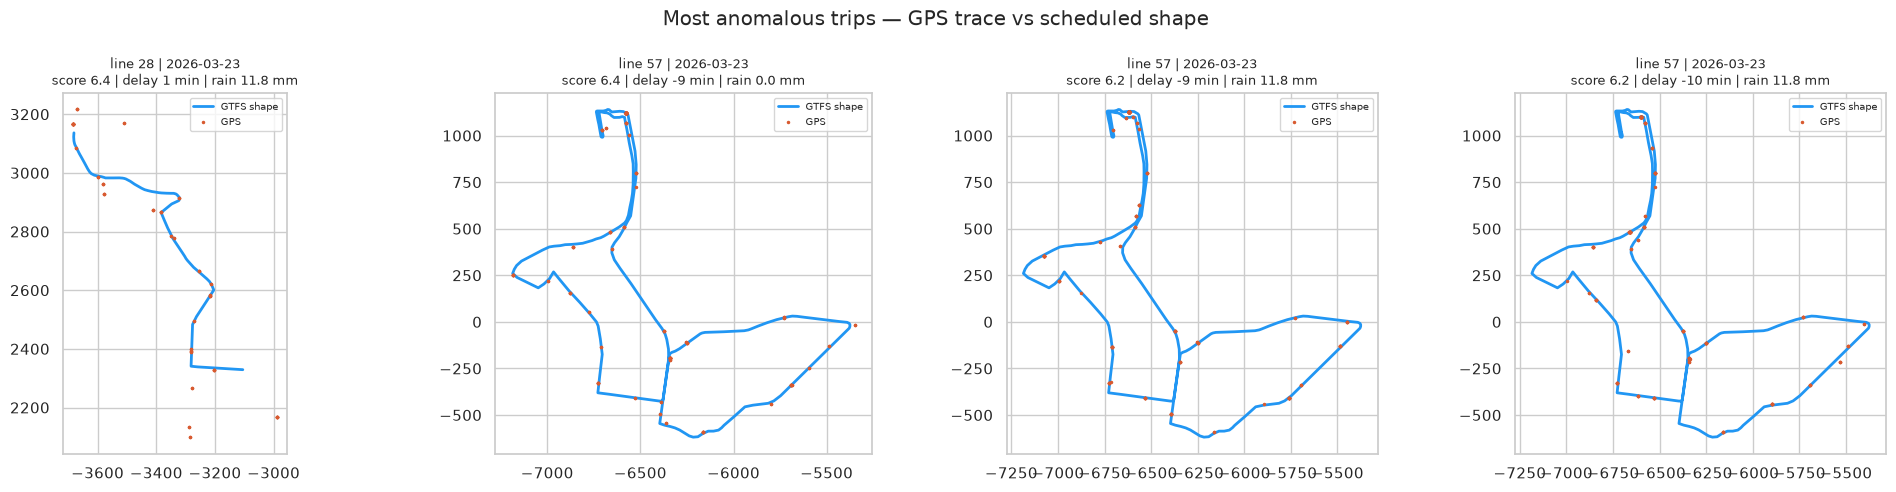

In [8]:
with open("./cache/gtfs_index.pkl", "rb") as f:
    gtfs_index = pickle.load(f)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (tid, row) in zip(axes, top20.head(4).iterrows()):
    raw = pd.read_csv(os.path.join(prep.MOBILITY_DIR, f"{row.date}.csv"))
    raw = raw[raw["tripId"] == row.trip_id]
    sched = prep.lookup_sched(gtfs_index, row.trip_id, row.date,
                              int(meta.loc[tid, "direction"]))
    pts = prep.to_local_xy(raw["lat"].to_numpy(), raw["lng"].to_numpy())
    ax.plot(sched.shape_xy[:, 0], sched.shape_xy[:, 1], "-",
            color="#2196F3", lw=2, label="GTFS shape")
    ax.plot(pts[:, 0], pts[:, 1], ".", color="#D85A30", ms=3, label="GPS")
    ax.set_title(f"line {row.line_id} | {row.date}\n"
                 f"score {row.score_mean:.1f} | delay {row.delay_min:.0f} min "
                 f"| rain {row.rain_mm_trip:.1f} mm", fontsize=9)
    ax.set_aspect("equal"); ax.legend(fontsize=7)
fig.suptitle("Most anomalous trips — GPS trace vs scheduled shape")
plt.tight_layout(); plt.savefig(f"{OUT}/top_anomalies_maps.png", dpi=140); plt.show()

## 6. Export & summary

In [9]:
export = df[["date", "line_id", "trip_id", "delayed", "degraded_day",
             "rain_mm_trip", "score_cnn", "score_lstm",
             "anom_cnn", "anom_lstm", "score_mean"]]
export.to_csv(f"{OUT}/anomaly_table.csv")
print("saved ->", f"{OUT}/anomaly_table.csv", f"({len(export)} trips)")
print("\nArtifacts:", sorted(os.listdir(OUT)))

saved -> ./artifacts_anomaly/anomaly_table.csv (22605 trips)

Artifacts: ['anomaly_table.csv', 'latent_tsne_3ways.png', 'per_day_scores.png', 'rain_vs_score.png', 'score_agreement.png', 'top20_anomalous_trips.csv', 'top_anomalies_maps.png']


In [10]:
print("── Summary ─────────────────────────────────────────────")
for tag in ("cnn", "lstm"):
    deg_rate = df.loc[df["degraded_day"] == 1, f"anom_{tag}"].mean()
    nor_rate = df.loc[df["degraded_day"] == 0, f"anom_{tag}"].mean()
    rainy_rate = df.loc[df["rainy"] == 1, f"anom_{tag}"].mean()
    dry_rate = df.loc[df["rainy"] == 0, f"anom_{tag}"].mean()
    dl = df.groupby(f"anom_{tag}")["delayed"].mean()
    print(f"  {tag.upper()}-AE: anomaly rate on degraded days {deg_rate:.1%} "
          f"(vs {nor_rate:.1%} normal); rainy {rainy_rate:.1%} vs dry {dry_rate:.1%}; "
          f"delayed share among anomalies {dl.get(True, float('nan')):.1%} "
          f"(vs {dl.get(False, float('nan')):.1%})")

── Summary ─────────────────────────────────────────────
  CNN-AE: anomaly rate on degraded days 4.3% (vs 5.1% normal); rainy 12.2% vs dry 4.4%; delayed share among anomalies 22.1% (vs 20.9%)
  LSTM-AE: anomaly rate on degraded days 2.4% (vs 5.3% normal); rainy 13.1% vs dry 4.4%; delayed share among anomalies 13.4% (vs 21.3%)
